# Speaker-Adaptive Visual Speech Recognition
### Few-Shot Personalization for Dysarthric Speakers

**Contribution.** A pretrained lip-reading model is adapted to an *individual* atypical speaker from only a handful of examples. We compare parameter-efficient **adapter** tuning against **full fine-tuning** under matched data budgets and report the resulting data-efficiency curve.

**Key engineering fix.** Per-frame face detection made the mouth crop jitter, destroying the lip-motion signal (loss pinned at chance). We estimate **one stable face box per clip** and apply it to every frame.

## 0 · Setup

In [2]:
# ============================================================
# 0.  SETUP  (local Windows / conda "dl-env", RTX 4050)
# ============================================================
import os, torch, numpy as np, random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert device.type == 'cuda', "CUDA not found — activate dl-env and check `torch.cuda.is_available()`"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# All project data lives HERE instead of Google Drive. Change if you want another folder.
ROOT = os.path.join(os.path.expanduser('~'), 'VSR_project')
os.makedirs(ROOT, exist_ok=True)

print("GPU:", torch.cuda.get_device_name(0))
print("VRAM: %.1f GB" % (torch.cuda.get_device_properties(0).total_memory / 1e9))
print("Root:", ROOT)


GPU: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.4 GB
Root: C:\Users\jhans\VSR_project


## 1 · Download GRID (source domain)

In [3]:
# ============================================================
# 1.  DOWNLOAD GRID  (source-domain corpus, typical speakers)
# ------------------------------------------------------------
#  Using 4 speakers instead of 1 -> ~4,000 clips, real speaker
#  diversity. Add more to SPEAKERS if you have time (each adds
#  ~1,000 clips, ~10-15 min download + preprocessing).
# ============================================================
import os, zipfile, tarfile, urllib.request

SPEAKERS = ['s1', 's2', 's3', 's4','s5','s6','s7','s8']
GRID_DIR = os.path.join(ROOT, 'grid')

def download(url, out_path):
    if os.path.exists(out_path):
        return
    print(f"Downloading {url} ...")
    urllib.request.urlretrieve(url, out_path)

for spk in SPEAKERS:
    spk_dir = os.path.join(GRID_DIR, spk)
    if os.path.exists(os.path.join(spk_dir, spk)):
        print(spk, "already downloaded, skipping")
        continue
    os.makedirs(spk_dir, exist_ok=True)
    v_zip = os.path.join(spk_dir, 'v.zip')
    a_tar = os.path.join(spk_dir, 'a.tar')
    download(f"https://spandh.dcs.shef.ac.uk/gridcorpus/{spk}/video/{spk}.mpg_vcd.zip", v_zip)
    download(f"https://spandh.dcs.shef.ac.uk/gridcorpus/{spk}/align/{spk}.tar", a_tar)
    with zipfile.ZipFile(v_zip) as z: z.extractall(spk_dir)
    with tarfile.open(a_tar) as t: t.extractall(spk_dir)
    print(spk, "done")

total = sum(len([f for f in os.listdir(os.path.join(GRID_DIR, s, s)) if f.endswith('.mpg')]) for s in SPEAKERS)
print(f"Total GRID videos across {len(SPEAKERS)} speakers: {total}")


s1 already downloaded, skipping
s2 already downloaded, skipping
s3 already downloaded, skipping
s4 already downloaded, skipping
s5 done
s6 done
s7 done
s8 done
Total GRID videos across 8 speakers: 8000


In [1]:
import cv2, os
print("cv2 file:", cv2.__file__)
print("cv2 version:", getattr(cv2, '__version__', 'NO VERSION ATTR — this is the problem'))
print("has CascadeClassifier:", hasattr(cv2, 'CascadeClassifier'))
print("cwd:", os.getcwd())
print("cv2.py or cv2/ in cwd?", 'cv2' in os.listdir('.') or 'cv2.py' in os.listdir('.'))

cv2 file: C:\Users\jhans\miniconda3\envs\dl-env\Lib\site-packages\cv2\__init__.py
cv2 version: 4.10.0
has CascadeClassifier: True
cwd: C:\Users\jhans\VSR_project
cv2.py or cv2/ in cwd? False


## 2 · Preprocessing — stable mouth ROI ⭐

In [4]:
# ============================================================
# 2.  PREPROCESSING  —  STABLE MOUTH ROI  (the critical fix)
# ------------------------------------------------------------
#  Prior failure mode: per-frame face detection made the crop box
#  jitter, which destroyed the lip-motion signal (loss pinned at
#  ln(4)=1.386, i.e. chance).  Fix: estimate ONE face box per clip
#  (median over sampled frames) and apply the SAME crop to every
#  frame -> temporal coherence preserved.
#  Now loops over all speakers in SPEAKERS (set in cell 1).
# ============================================================
import os, cv2, numpy as np
from tqdm import tqdm

OUT_H, OUT_W = 50, 100
CASCADE = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')


def read_alignment(path):
    out = []
    with open(path) as f:
        for line in f:
            p = line.split()
            if len(p) == 3 and p[2] not in ('sil', 'sp'):
                out.append(p[2])
    return out


def stable_mouth_roi(video_path, out_hw=(OUT_H, OUT_W)):
    """Return (T,H,W) uint8 mouth ROI using ONE fixed crop for the whole clip."""
    cap = cv2.VideoCapture(video_path); frames = []
    while True:
        ok, fr = cap.read()
        if not ok: break
        frames.append(fr)
    cap.release()
    if not frames: return None

    boxes = []
    for i in np.linspace(0, len(frames)-1, 8).astype(int):
        det = CASCADE.detectMultiScale(cv2.cvtColor(frames[i], cv2.COLOR_BGR2GRAY), 1.1, 5)
        if len(det): boxes.append(det[0])
    if not boxes: return None

    x, y, w, h = np.median(np.array(boxes), axis=0).astype(int)   # robust, stable
    H, W = frames[0].shape[:2]
    y1, y2 = max(0, y+int(h*0.58)), min(H, y+int(h*1.02))
    x1, x2 = max(0, x+int(w*0.16)), min(W, x+int(w*0.84))
    if y2-y1 < 10 or x2-x1 < 10: return None

    roi = [cv2.resize(cv2.cvtColor(f[y1:y2, x1:x2], cv2.COLOR_BGR2GRAY),
                      (out_hw[1], out_hw[0])) for f in frames]
    return np.array(roi, dtype=np.uint8)


# ---------- build vocab across ALL speakers ----------
all_align_dirs = [os.path.join(GRID_DIR, spk, 'align') for spk in SPEAKERS]
vocab = sorted({w for align_dir in all_align_dirs
                for fn in os.listdir(align_dir) if fn.endswith('.align')
                for w in read_alignment(os.path.join(align_dir, fn))})
w2i = {w: i for i, w in enumerate(vocab)}
np.save(os.path.join(ROOT, 'vocab.npy'), np.array(vocab))
print("Vocabulary:", len(vocab), "words")

# ---------- process every speaker ----------
X, Y, skipped = [], [], 0
for spk in SPEAKERS:
    video_dir = os.path.join(GRID_DIR, spk, spk)
    align_dir = os.path.join(GRID_DIR, spk, 'align')
    names = sorted(f[:-4] for f in os.listdir(video_dir) if f.endswith('.mpg'))
    for nm in tqdm(names, desc=f"Stable-crop preprocessing [{spk}]"):
        try:
            roi   = stable_mouth_roi(os.path.join(video_dir, nm + '.mpg'))
            words = read_alignment(os.path.join(align_dir, nm + '.align'))
            if roi is not None and roi.shape[0] == 75 and len(words) == 6:
                X.append(roi); Y.append([w2i[w] for w in words])
            else: skipped += 1
        except Exception: skipped += 1

X = np.stack(X); Y = np.array(Y)
np.save(os.path.join(ROOT, 'X_grid.npy'), X); np.save(os.path.join(ROOT, 'Y_grid.npy'), Y)
print(f"\nSaved {X.shape[0]} clips ({X.nbytes/1e6:.0f} MB)   skipped {skipped}")


Vocabulary: 51 words


Stable-crop preprocessing [s8]: 100%|██████████| 1000/1000 [05:15<00:00,  3.16it/s]



Saved 7859 clips (2947 MB)   skipped 141


## 3 · Model: 3D-CNN + BiGRU + CTC

In [5]:
# ============================================================
# 3.  MODEL  —  3D-CNN  +  BiGRU  +  CTC   (LipNet-style)
# ============================================================
import torch, torch.nn as nn

class LipNet(nn.Module):
    def __init__(self, vocab_size, hidden=256, dropout=0.4):
        super().__init__()
        self.frontend = nn.Sequential(                       # spatio-temporal front-end
            nn.Conv3d(1, 32, (3,5,5), padding=(1,2,2)), nn.BatchNorm3d(32), nn.ReLU(True),
            nn.MaxPool3d((1,2,2)), nn.Dropout3d(dropout),
            nn.Conv3d(32, 64, (3,5,5), padding=(1,2,2)), nn.BatchNorm3d(64), nn.ReLU(True),
            nn.MaxPool3d((1,2,2)), nn.Dropout3d(dropout),
            nn.Conv3d(64, 96, (3,3,3), padding=(1,1,1)), nn.BatchNorm3d(96), nn.ReLU(True),
            nn.MaxPool3d((1,2,2)), nn.Dropout3d(dropout),
        )
        self.feat_dim = 96 * 6 * 12                          # C x h x w after pooling
        self.gru1 = nn.GRU(self.feat_dim, hidden, batch_first=True, bidirectional=True)
        self.gru2 = nn.GRU(hidden*2,     hidden, batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden*2, vocab_size + 1)      # +1 = CTC blank
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv3d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)

    def encode(self, x):                    # x (B,T,H,W) float 0-1
        x = self.frontend(x.unsqueeze(1))   # (B,96,T,h,w)
        B, C, T, h, w = x.shape
        x = x.permute(0,2,1,3,4).reshape(B, T, C*h*w)
        x, _ = self.gru1(x); x, _ = self.gru2(x)
        return self.drop(x)                 # (B,T,2H)

    def forward(self, x):
        return self.head(self.encode(x))    # (B,T,V+1)


def ctc_decode(logits, blank, vocab):
    """Greedy CTC decode: argmax -> collapse repeats -> drop blanks."""
    ids, out, prev = logits.argmax(-1).tolist(), [], None
    for k in ids:
        if k != prev and k != blank: out.append(vocab[k])
        prev = k
    return out


def edit_distance(a, b):
    d = [[0]*(len(b)+1) for _ in range(len(a)+1)]
    for i in range(len(a)+1): d[i][0] = i
    for j in range(len(b)+1): d[0][j] = j
    for i in range(1, len(a)+1):
        for j in range(1, len(b)+1):
            d[i][j] = min(d[i-1][j]+1, d[i][j-1]+1,
                          d[i-1][j-1] + (a[i-1] != b[j-1]))
    return d[-1][-1]

def wer(ref, hyp): return edit_distance(ref, hyp) / max(1, len(ref))
def cer(ref, hyp):
    r, h = ' '.join(ref), ' '.join(hyp)
    return edit_distance(list(r), list(h)) / max(1, len(r))

print("Model + metrics defined.")

Model + metrics defined.


## 4 · Train the source model

In [6]:
# ============================================================
# 4.  TRAIN THE SOURCE MODEL  (typical speakers)
# ============================================================
import numpy as np, torch, torch.nn as nn, time


X = np.load(f'{ROOT}/X_grid.npy'); Y = np.load(f'{ROOT}/Y_grid.npy')
vocab = list(np.load(f'{ROOT}/vocab.npy')); V = len(vocab); BLANK = V

Xt = torch.from_numpy(X)
Yt = [torch.tensor(s, dtype=torch.long) for s in Y]
g  = torch.Generator().manual_seed(42)
p  = torch.randperm(len(Xt), generator=g)
Xt = Xt[p]; Yt = [Yt[i] for i in p.tolist()]
ntr = int(0.9*len(Xt))
Xtr, Xte = Xt[:ntr], Xt[ntr:]
Ytr, Yte = Yt[:ntr], Yt[ntr:]
print(f"train {len(Xtr)} | test {len(Xte)} | vocab {V}")

model = LipNet(V).to(device)
opt   = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=80)
ctc   = nn.CTCLoss(blank=BLANK, zero_infinity=True)
scaler = torch.cuda.amp.GradScaler()
BS, EPOCHS = 16, 80
print(f"params {sum(q.numel() for q in model.parameters()):,}\n")

hist = []
for ep in range(EPOCHS):
    model.train(); perm = torch.randperm(len(Xtr)); tot = nb = 0; t0 = time.time()
    for i in range(0, len(Xtr), BS):
        idx = perm[i:i+BS].tolist()
        bx  = Xtr[idx].to(device, non_blocking=True).float().div_(255.)
        tgt = torch.cat([Ytr[j] for j in idx]).to(device)
        il  = torch.full((len(idx),), 75//1, dtype=torch.long)
        tl  = torch.tensor([len(Ytr[j]) for j in idx], dtype=torch.long)
        opt.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            out = model(bx)
            il  = torch.full((len(idx),), out.shape[1], dtype=torch.long)
            loss = ctc(out.float().log_softmax(2).permute(1,0,2), tgt, il, tl)
        scaler.scale(loss).backward()
        scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(opt); scaler.update()
        tot += loss.item(); nb += 1; del bx
    sched.step(); hist.append(tot/nb)
    if ep % 5 == 0 or ep == EPOCHS-1:
        print(f"epoch {ep+1:3d}/{EPOCHS}  ctc {tot/nb:6.3f}   ({time.time()-t0:.0f}s)")

torch.save({'model': model.state_dict(), 'vocab': vocab}, f'{ROOT}/source_model.pt')
np.save(f'{ROOT}/train_hist.npy', np.array(hist))
print("\nSaved source model.")

train 7073 | test 786 | vocab 51


C:\Users\jhans\AppData\Local\Temp\ipykernel_35688\300392104.py:24: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\jhans\AppData\Local\Temp\ipykernel_35688\300392104.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


params 12,544,980

epoch   1/80  ctc  2.928   (139s)
epoch   6/80  ctc  1.915   (138s)
epoch  11/80  ctc  1.883   (139s)
epoch  16/80  ctc  1.869   (138s)
epoch  21/80  ctc  1.863   (137s)
epoch  26/80  ctc  1.858   (137s)
epoch  31/80  ctc  1.855   (137s)
epoch  36/80  ctc  1.853   (136s)
epoch  41/80  ctc  1.851   (136s)
epoch  46/80  ctc  1.766   (136s)
epoch  51/80  ctc  1.524   (137s)
epoch  56/80  ctc  1.276   (135s)
epoch  61/80  ctc  1.125   (136s)
epoch  66/80  ctc  1.026   (137s)
epoch  71/80  ctc  0.975   (136s)
epoch  76/80  ctc  0.952   (136s)
epoch  80/80  ctc  0.949   (136s)

Saved source model.


## 5 · Baseline evaluation (WER / CER)

In [7]:
# ============================================================
# 5.  EVALUATE THE SOURCE MODEL  (baseline WER / CER)
# ============================================================
model.eval(); W = C = 0.0; shown = 0
with torch.no_grad():
    for i in range(len(Xte)):
        bx  = Xte[i:i+1].to(device).float().div_(255.)
        hyp = ctc_decode(model(bx)[0].float().cpu(), BLANK, vocab)
        ref = [vocab[k] for k in Yte[i].tolist()]
        W  += wer(ref, hyp); C += cer(ref, hyp)
        if shown < 6:
            print(f"REF: {' '.join(ref)}\nHYP: {' '.join(hyp) if hyp else '(empty)'}\n")
            shown += 1
        del bx

baseline_wer = W/len(Xte)*100
baseline_cer = C/len(Xte)*100
print(f"BASELINE  WER {baseline_wer:.1f}%   CER {baseline_cer:.1f}%")

REF: set blue with a nine soon
HYP: set blue with k nine soon

REF: set green by v six soon
HYP: set red by t zero soon

REF: place blue in u six soon
HYP: place blue at u three soon

REF: bin red in e nine now
HYP: bin red in k nine now

REF: set green in i four please
HYP: set green in l four please

REF: lay white in k five soon
HYP: lay white in f five soon

BASELINE  WER 32.0%   CER 18.1%


In [9]:
import os
print(os.path.exists(r'C:\Users\jhans\VSR_project\UASpeech_F05.tgz'))

True


## 6 · UASpeech — segment dysarthric video into word clips

In [10]:
# ============================================================
# 6.  UASPEECH  —  SEGMENT DYSARTHRIC VIDEO INTO WORD CLIPS
# ------------------------------------------------------------
#  Each .divx is one long recording per (speaker, block).  The file
#  <SPK>_<BLK>_frame_index.txt gives  Utterance | Begin | End  in FRAMES,
#  so we can cut precise word-level clips.
#  Speakers: M*/F* = dysarthric (CP);  CM*/CF* = control.
# ============================================================
import tarfile, os, cv2, numpy as np, re
from tqdm import tqdm

# ROOT already set in cell 0.
# Manually copy UASpeech_video_0.tgz from your Google Drive into ROOT first
# (Drive > right-click file > Download), OR set TGZ to wherever you saved it.
TGZ  = os.path.join(ROOT, 'UASpeech_F05.tgz')
assert os.path.exists(TGZ), f"Put UASpeech_video_0.tgz at {TGZ} first (download it from Drive)."
WORK = os.path.join(ROOT, 'ua'); os.makedirs(WORK, exist_ok=True)
T_LEN, OUT_H, OUT_W = 75, 50, 100     # match the source domain


def parse_frame_index(text):
    """-> list of (utterance_id, begin_frame, end_frame)"""
    rows = []
    for line in text.splitlines():
        m = re.match(r'\s*(\S+)\s+(\d+)\s+(\d+)\s*$', line)
        if m: rows.append((m.group(1), int(m.group(2)), int(m.group(3))))
    return rows


def resample_to(frames, n=T_LEN):
    """Uniformly resample a variable-length clip to exactly n frames."""
    if len(frames) == 0: return None
    idx = np.linspace(0, len(frames)-1, n).round().astype(int)
    return np.stack([frames[i] for i in idx])


def segment_speaker(tar, speaker, block='B1'):
    """Return list of (word_code, (T,H,W) uint8) for one speaker/block."""
    vid_name = f'UASpeech/video/{speaker}/{speaker}-{block}-DV-1.divx'
    idx_name = f'UASpeech/video/{speaker}/{speaker}_{block}_frame_index.txt'
    names = tar.getnames()
    if vid_name not in names or idx_name not in names: return []

    rows = parse_frame_index(tar.extractfile(idx_name).read().decode('utf8','ignore'))

    tmp = os.path.join(WORK, f'{speaker}_{block}.divx')
    if not os.path.exists(tmp):
        with open(tmp, 'wb') as f: f.write(tar.extractfile(vid_name).read())

    cap = cv2.VideoCapture(tmp); frames = []
    while True:
        ok, fr = cap.read()
        if not ok: break
        frames.append(fr)
    cap.release()
    if not frames: return []

    # one stable face box for the whole recording
    boxes = []
    for i in np.linspace(0, len(frames)-1, 12).astype(int):
        det = CASCADE.detectMultiScale(cv2.cvtColor(frames[i], cv2.COLOR_BGR2GRAY), 1.1, 5)
        if len(det): boxes.append(det[0])
    if not boxes: return []
    x, y, w, h = np.median(np.array(boxes), axis=0).astype(int)
    H, W = frames[0].shape[:2]
    y1, y2 = max(0, y+int(h*0.58)), min(H, y+int(h*1.02))
    x1, x2 = max(0, x+int(w*0.16)), min(W, x+int(w*0.84))

    rois = [cv2.resize(cv2.cvtColor(f[y1:y2, x1:x2], cv2.COLOR_BGR2GRAY), (OUT_W, OUT_H))
            for f in frames]

    out = []
    for utt, b, e in rows:
        if e <= b or e > len(rois): continue
        clip = resample_to(rois[b:e], T_LEN)
        if clip is not None:
            out.append((utt, clip.astype(np.uint8)))
    return out


# ---- run over available speakers ----
tar = tarfile.open(TGZ, 'r:gz')
speakers = sorted({n.split('/')[2] for n in tar.getnames()
                   if n.startswith('UASpeech/video/') and len(n.split('/')) > 3})
print("Speakers found:", speakers)

data = {}
for spk in tqdm(speakers, desc="Segmenting UASpeech"):
    clips = []
    for blk in ['B1', 'B2', 'B3']:
        clips += segment_speaker(tar, spk, blk)
    if clips:
        data[spk] = clips
        print(f"  {spk}: {len(clips)} word clips")
tar.close()

np.save(os.path.join(ROOT, 'ua_segmented.npy'), np.array(data, dtype=object), allow_pickle=True)
print("\nSaved segmented UASpeech.")

Speakers found: ['F05']


Segmenting UASpeech: 100%|██████████| 1/1 [05:49<00:00, 349.51s/it]

  F05: 765 word clips



Saved segmented UASpeech.


## 7 · **Novelty** — few-shot speaker personalization

In [11]:
# ============================================================
# 7.  *** NOVELTY ***  FEW-SHOT SPEAKER PERSONALIZATION
# ------------------------------------------------------------
#  Compare three adaptation strategies under a matched data budget:
#    (a) zero-shot        - no adaptation (the gap)
#    (b) full fine-tune   - update all weights
#    (c) adapter layers   - freeze backbone, train a small adapter
#  and sweep k = 1,3,5,10,20 examples  ->  data-efficiency curve.
# ============================================================
import copy, numpy as np, torch, torch.nn as nn

class Adapter(nn.Module):
    """Parameter-efficient speaker adapter inserted before the CTC head."""
    def __init__(self, dim, bottleneck=64):
        super().__init__()
        self.down = nn.Linear(dim, bottleneck)
        self.up   = nn.Linear(bottleneck, dim)
        self.act  = nn.ReLU(True)
        nn.init.zeros_(self.up.weight); nn.init.zeros_(self.up.bias)   # identity at init
    def forward(self, x):
        return x + self.up(self.act(self.down(x)))                     # residual


class PersonalizedLipNet(nn.Module):
    def __init__(self, base: LipNet, mode='adapter'):
        super().__init__()
        self.base = base
        self.mode = mode
        dim = base.head.in_features
        self.adapter = Adapter(dim).to(next(base.parameters()).device) if mode == 'adapter' else None
        if mode == 'adapter':                       # freeze the backbone
            for p in self.base.parameters(): p.requires_grad = False
            for p in self.base.head.parameters(): p.requires_grad = True
    def forward(self, x):
        z = self.base.encode(x)
        if self.adapter is not None: z = self.adapter(z)
        return self.base.head(z)


def evaluate(net, X, Y, vocab, blank, bs=4):
    net.eval(); W = C = 0.0
    with torch.no_grad():
        for i in range(len(X)):
            bx  = X[i:i+1].to(device).float().div_(255.)
            hyp = ctc_decode(net(bx)[0].float().cpu(), blank, vocab)
            ref = [vocab[k] for k in Y[i]]
            W += wer(ref, hyp); C += cer(ref, hyp); del bx
    return W/len(X)*100, C/len(X)*100


def personalize(base_state, Xs, Ys, k, mode, vocab, blank, epochs=40, lr=1e-4):
    """Adapt to ONE speaker using k support examples; return the adapted model."""
    base = LipNet(len(vocab)).to(device); base.load_state_dict(base_state)
    net  = PersonalizedLipNet(base, mode=mode).to(device) if mode != 'full' else base
    params = [p for p in net.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=lr)
    ctc = nn.CTCLoss(blank=blank, zero_infinity=True)

    Xk, Yk = Xs[:k], Ys[:k]
    net.train()
    for _ in range(epochs):
        for i in range(0, len(Xk), 2):
            bx  = Xk[i:i+2].to(device).float().div_(255.)
            ys  = Yk[i:i+2]
            tgt = torch.cat([torch.tensor(t) for t in ys]).to(device)
            tl  = torch.tensor([len(t) for t in ys], dtype=torch.long)
            opt.zero_grad(set_to_none=True)
            out = net(bx)
            il  = torch.full((len(ys),), out.shape[1], dtype=torch.long)
            loss = ctc(out.log_softmax(2).permute(1,0,2), tgt, il, tl)
            loss.backward(); torch.nn.utils.clip_grad_norm_(params, 5.0); opt.step()
            del bx
    return net


print("Personalization module ready (zero-shot | full fine-tune | adapter).")

Personalization module ready (zero-shot | full fine-tune | adapter).


In [15]:
import numpy as np, os
ua = np.load(os.path.join(ROOT, 'ua_segmented.npy'), allow_pickle=True).item()
print("Speakers in ua:", list(ua.keys()))
for spk, clips in ua.items():
    print(spk, "-> total clips:", len(clips))
    print("First 10 utterance codes:", [c[0] for c in clips[:10]])

Speakers in ua: ['F05']
F05 -> total clips: 765
First 10 utterance codes: ['F05_B1_D3', 'F05_B1_D9', 'F05_B1_D0', 'F05_B1_D6', 'F05_B1_D7', 'F05_B1_D8', 'F05_B1_D4', 'F05_B1_D5', 'F05_B1_D1', 'F05_B1_D2']


## 8 · Experiment — data-efficiency curve

In [16]:
# ============================================================
# 8.  EXPERIMENT  —  data-efficiency curve  (the paper result)
# ============================================================
import numpy as np, torch, json

ck    = torch.load(os.path.join(ROOT, 'source_model.pt') , weights_only=False)
vocab = ck['vocab']; V = len(vocab); BLANK = V
base_state = ck['model']

ua = np.load(os.path.join(ROOT, 'ua_segmented.npy'), allow_pickle=True).item()

# word-code -> label ids  (single-word utterances)
DIGIT_WORDS = ['zero','one','two','three','four','five','six','seven','eight','nine']

def utt_to_label(utt):
    code = utt.split('_')[-1].upper()          # e.g. F05_B1_D3 -> D3
    if code.startswith('D') and code[1:].isdigit():
        word = DIGIT_WORDS[int(code[1:])]
        if word in vocab:
            return [vocab.index(word)]
    return None
results = {}
KS = [0, 1, 3, 5, 10, 20]
MODES = ['adapter', 'full']

for spk, clips in ua.items():
    Xs, Ys = [], []
    for utt, clip in clips:
        lab = utt_to_label(utt)
        if lab: Xs.append(clip); Ys.append(lab)
    if len(Xs) < 30: continue
    Xs = torch.from_numpy(np.stack(Xs))
    idx = torch.randperm(len(Xs), generator=torch.Generator().manual_seed(0))
    Xs, Ys = Xs[idx], [Ys[i] for i in idx.tolist()]
    Xq, Yq = Xs[-20:], Ys[-20:]                # held-out query set
    Xsup, Ysup = Xs[:-20], Ys[:-20]            # support pool

    results[spk] = {}
    for mode in MODES:
        curve = []
        for k in KS:
            if k == 0:
                net = LipNet(V).to(device); net.load_state_dict(base_state)
            else:
                net = personalize(base_state, Xsup, Ysup, k, mode, vocab, BLANK)
            w, c = evaluate(net, Xq, Yq, vocab, BLANK)
            curve.append({'k': k, 'wer': w, 'cer': c})
            print(f"{spk:>5} | {mode:>7} | k={k:2d} -> WER {w:5.1f}%  CER {c:5.1f}%")
            del net; torch.cuda.empty_cache()
        results[spk][mode] = curve

with open(os.path.join(ROOT, 'results.json'), 'w') as f: json.dump(results, f, indent=2)
print("\nSaved results.json")

  F05 | adapter | k= 0 -> WER 590.0%  CER 565.9%
  F05 | adapter | k= 1 -> WER 590.0%  CER 582.0%
  F05 | adapter | k= 3 -> WER 280.0%  CER 252.8%
  F05 | adapter | k= 5 -> WER 105.0%  CER  92.2%
  F05 | adapter | k=10 -> WER  95.0%  CER  87.0%
  F05 | adapter | k=20 -> WER  95.0%  CER  87.0%
  F05 |    full | k= 0 -> WER 590.0%  CER 565.9%
  F05 |    full | k= 1 -> WER 355.0%  CER 358.8%
  F05 |    full | k= 3 -> WER 140.0%  CER 155.2%
  F05 |    full | k= 5 -> WER  90.0%  CER  80.8%
  F05 |    full | k=10 -> WER  95.0%  CER  88.2%
  F05 |    full | k=20 -> WER  90.0%  CER  83.2%

Saved results.json


## 9 · Figure for the paper

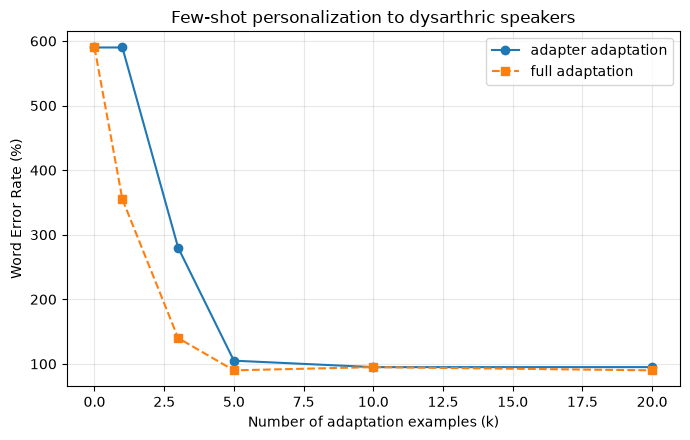

Saved fig_data_efficiency.png


In [17]:
# ============================================================
# 9.  FIGURES  —  data-efficiency curve for the paper
# ============================================================
import json, numpy as np, matplotlib.pyplot as plt

res  = json.load(open(os.path.join(ROOT, 'results.json')))
KS   = [0,1,3,5,10,20]

plt.figure(figsize=(7,4.5))
for mode, style in [('adapter','-o'), ('full','--s')]:
    curves = [[p['wer'] for p in res[s][mode]] for s in res if mode in res[s]]
    if not curves: continue
    mean = np.mean(curves, axis=0); std = np.std(curves, axis=0)
    plt.plot(KS, mean, style, label=f'{mode} adaptation')
    plt.fill_between(KS, mean-std, mean+std, alpha=0.15)

plt.xlabel('Number of adaptation examples (k)')
plt.ylabel('Word Error Rate (%)')
plt.title('Few-shot personalization to dysarthric speakers')
plt.grid(alpha=.3); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'fig_data_efficiency.png'), dpi=200)
plt.show()
print("Saved fig_data_efficiency.png")